In [181]:
#Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [182]:
#Import the data file
df = pd.read_csv(r"toyota_used_car_data.csv")
#Displays the data
df

,Name,Price($),Milage,Review,Review_count,Badge
0,2021 Toyota Camry SE,"31,150","13,390",4.5,659,Good Deal
1,2021 Toyota Supra 3.0 Premium,"58,981","7,348",4.8,"2,744",Great Deal
2,2019 Toyota Sequoia Platinum,"51,999","55,121",4.5,"2,092",Great Deal
3,2019 Toyota Camry SE,"25,689","49,126",1.0,1,Good Deal
4,2017 Toyota Highlander Limited,"31,591","84,621",4.9,"1,745",Good Deal
...,...,...,...,...,...,...
995,2019 Toyota RAV4 Hybrid XLE,"36,981","11,872",4.4,640,Good Deal
996,2010 Toyota Prius IV,"7,995","1,90,884",4.7,"1,432",Good Deal
997,2000 Toyota 4Runner SR5,"15,995","1,45,199",4.1,11,Home Delivery
998,2019 Toyota Corolla LE,"19,989","23,814",4.9,337,Good Deal


In [183]:
# Summarises the data
print('Key Info')
print(df.info())
print(' ')
print('Simple metrics about data')
print(df.describe())

Key Info
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          1000 non-null   str    
 1   Price($)      1000 non-null   str    
 2   Milage        1000 non-null   str    
 3   Review        997 non-null    float64
 4   Review_count  1000 non-null   str    
 5   Badge         977 non-null    str    
dtypes: float64(1), str(5)
memory usage: 47.0 KB
None
 
Simple metrics about data
           Review
count  997.000000
mean     4.448847
std      0.591702
min      1.000000
25%      4.400000
50%      4.600000
75%      4.800000
max      5.000000


In [195]:
#Need to change the data types for the fields: price, mileage, and review count
cols = ["Price($)", "Milage", "Review_count"]
for col in cols:
    df[col] = (df[col].astype(str).str.replace(",", "").astype(int))

In [185]:
#Displays the first 10 rows
df["Name"].head(10)

0              2021 Toyota Camry SE
1     2021 Toyota Supra 3.0 Premium
2      2019 Toyota Sequoia Platinum
3              2019 Toyota Camry SE
4    2017 Toyota Highlander Limited
5             2021 Toyota Supra 3.0
6       2013 Toyota Land Cruiser V8
7              2019 Toyota Camry SE
8              2019 Toyota Camry SE
9            2017 Toyota Corolla LE
Name: Name, dtype: str

In [186]:
#Splitting the column 'Name' into year and model
df["Year"] = df["Name"].str.split().str[0].astype(int)
df["Model"] = df["Name"].str.split().str[2:].str.join(" ")
df

,Name,Price($),Milage,Review,Review_count,Badge,Year,Model
0,2021 Toyota Camry SE,31150,13390,4.5,659,Good Deal,2021,Camry SE
1,2021 Toyota Supra 3.0 Premium,58981,7348,4.8,2744,Great Deal,2021,Supra 3.0 Premium
2,2019 Toyota Sequoia Platinum,51999,55121,4.5,2092,Great Deal,2019,Sequoia Platinum
3,2019 Toyota Camry SE,25689,49126,1.0,1,Good Deal,2019,Camry SE
4,2017 Toyota Highlander Limited,31591,84621,4.9,1745,Good Deal,2017,Highlander Limited
...,...,...,...,...,...,...,...,...
995,2019 Toyota RAV4 Hybrid XLE,36981,11872,4.4,640,Good Deal,2019,RAV4 Hybrid XLE
996,2010 Toyota Prius IV,7995,190884,4.7,1432,Good Deal,2010,Prius IV
997,2000 Toyota 4Runner SR5,15995,145199,4.1,11,Home Delivery,2000,4Runner SR5
998,2019 Toyota Corolla LE,19989,23814,4.9,337,Good Deal,2019,Corolla LE


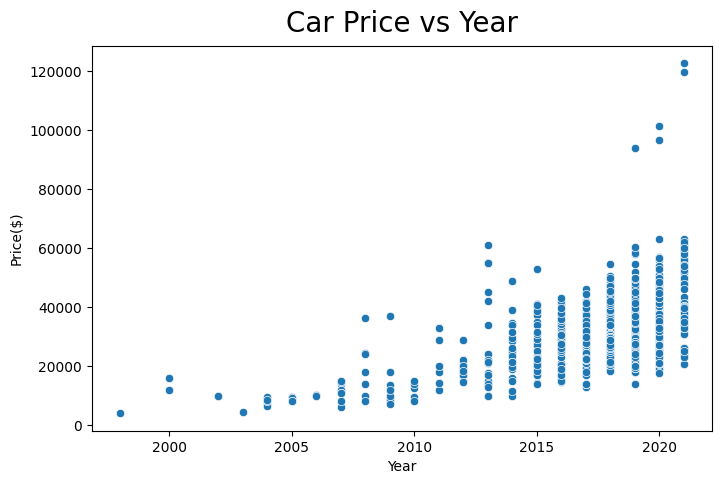

In [187]:
#Scatter plot for Car Price vs Year
plt.figure(figsize=(8,5))
sns.scatterplot(df, x="Year", y="Price($)")
plt.title("Car Price vs Year", pad=10, fontsize=20)
plt.show()

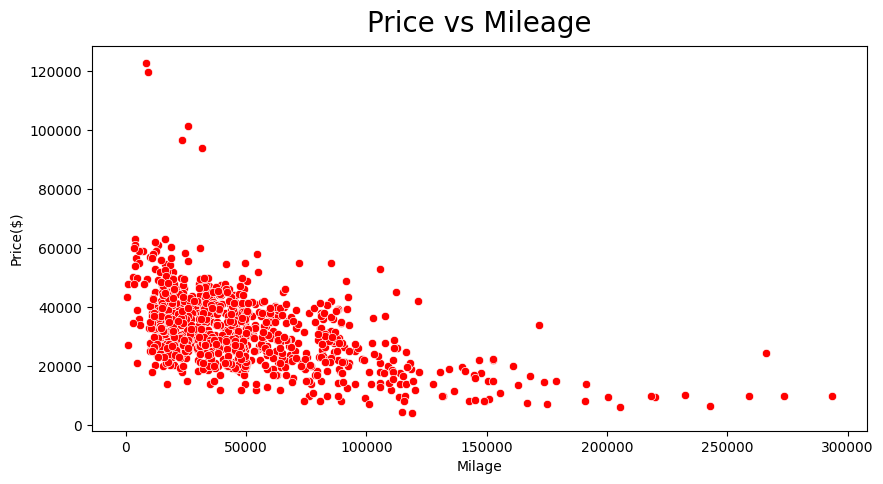

In [188]:
#Scatter plot for Price vs Mileage
plt.figure(figsize=(10,5))
sns.scatterplot(df, x="Milage", y="Price($)", color='red')
plt.title("Price vs Mileage", pad=10, fontsize=20)
plt.show()

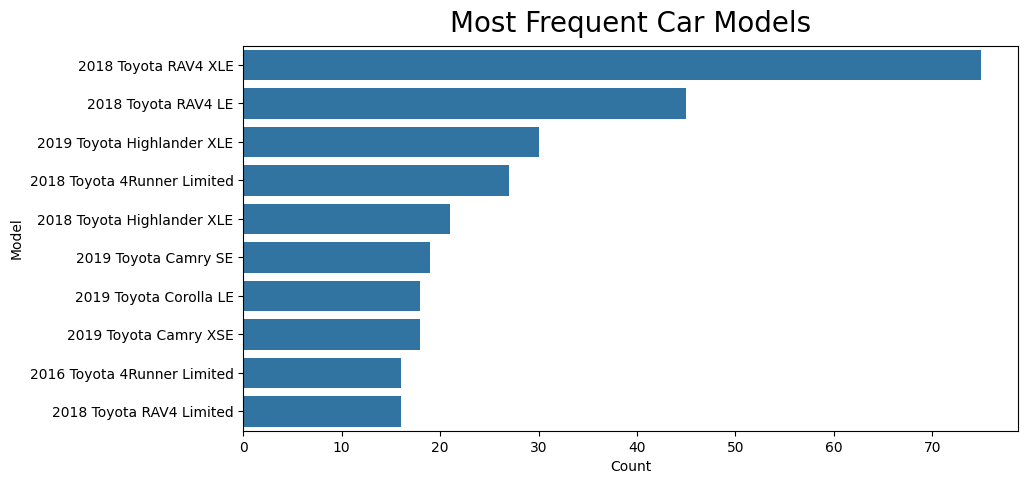

In [189]:
#Most frequent models
top_models = df["Name"].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_models.values, y=top_models.index)
plt.title("Most Frequent Car Models", pad=10, fontsize=20)
plt.xlabel("Count")
plt.ylabel("Model")
plt.show()

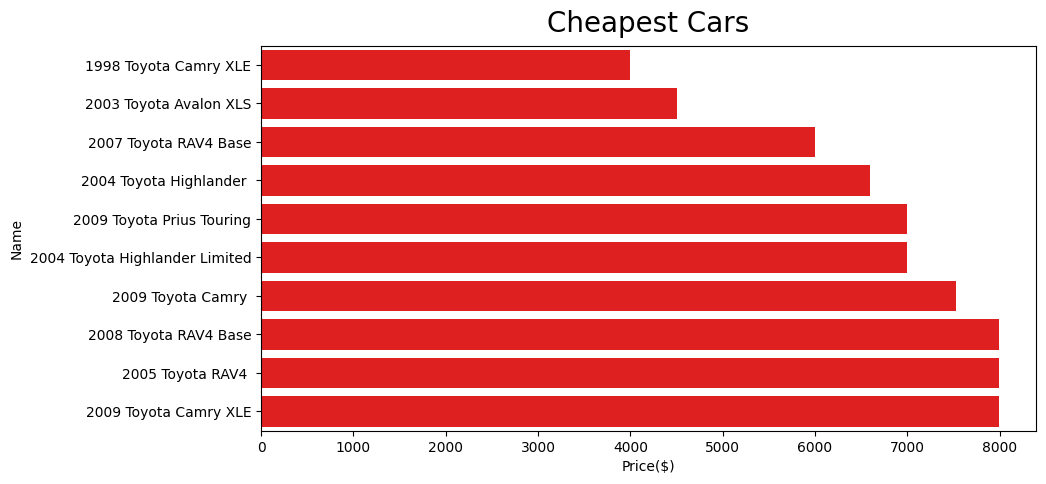

In [190]:
#Cheapest Cars
cheap_cars = df.sort_values(by="Price($)", ascending=True).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=cheap_cars, x="Price($)", y="Name", color='red')
plt.title("Cheapest Cars", pad=10, fontsize=20)
plt.show()

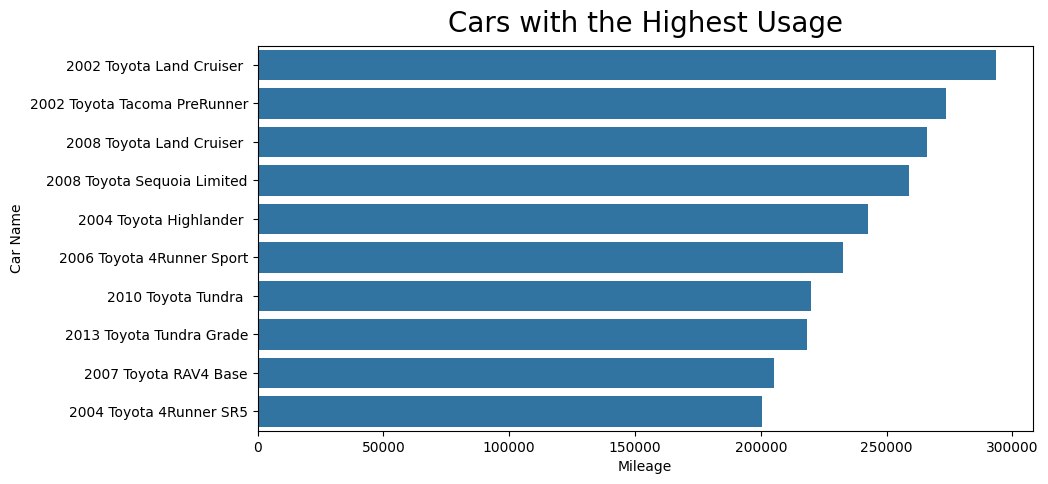

In [191]:
#Cars with the Highest Usage
top_mileage = df[['Name', 'Milage']].sort_values(by='Milage', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_mileage, x='Milage', y='Name')
plt.title('Cars with the Highest Usage', pad=10, fontsize=20)
plt.xlabel('Mileage')
plt.ylabel('Car Name')
plt.show()

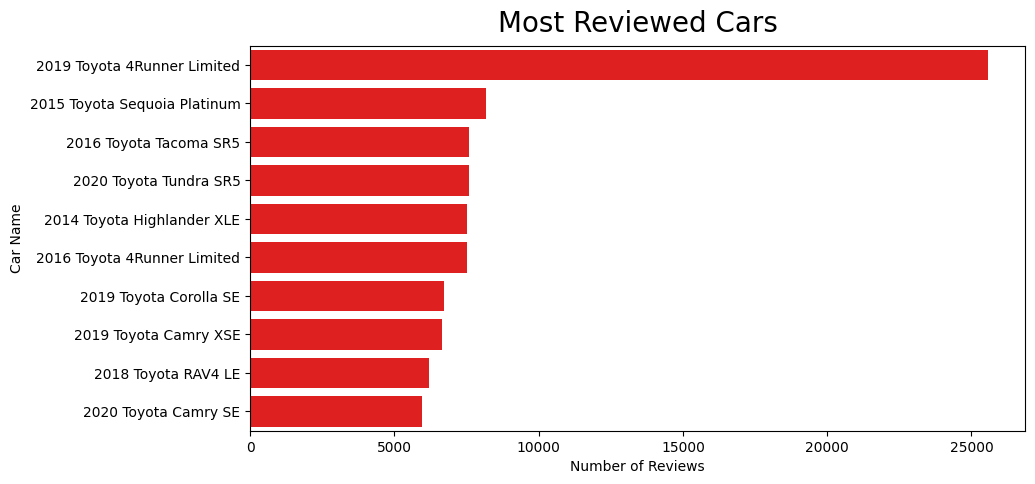

In [192]:
#Most Reviewed Cars
top_reviewed = df.query('Review_count > 500').sort_values(by='Review_count', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_reviewed, x='Review_count', y='Name', color='red')
plt.title('Most Reviewed Cars', pad=10, fontsize=20)
plt.xlabel('Number of Reviews')
plt.ylabel('Car Name')
plt.show()

In [193]:
#Correlation matrix of numeric features
df.corr(numeric_only=True)

,Price($),Milage,Review,Review_count,Year
Price($),1.000000,-0.479431,0.108642,0.089736,0.505272
Milage,-0.479431,1.000000,-0.099768,-0.096231,-0.757773
Review,0.108642,-0.099768,1.000000,0.281577,0.112472
Review_count,0.089736,-0.096231,0.281577,1.000000,0.111410
Year,0.505272,-0.757773,0.112472,0.111410,1.000000


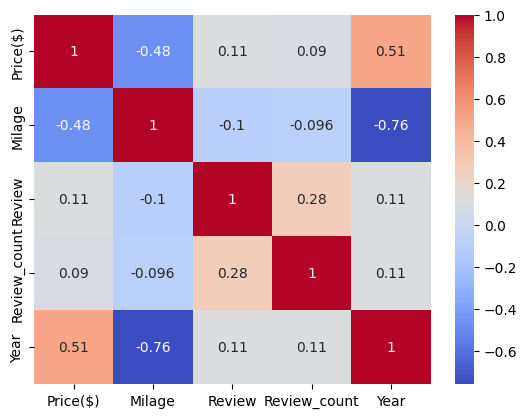

In [194]:
# Heatmap of correlations between variables
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()